In [12]:
from pathlib import Path
import gzip
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from stable_platform_matchings.domain.instance import Instance
import seaborn as sns
from matplotlib.ticker import PercentFormatter

In [2]:
sns.set_theme(context="paper", style="ticks")

In [3]:
root = Path("../results/exp_5")
all_jsons = list(root.rglob("*.json.gz"))
graph_data_filename = "../data/graph_0-14960_00_new.pickle"
instance = Instance.from_yaml(Path('../data/anon_14_day_instances/2020-08-27.yaml'))

In [4]:
LC_TO_USD = instance.lc_to_usd
TRUCK_FIXED_COST = instance.truck_fixed_cost

MAX_DEVIATION_POTENTIAL = 12

DEV_POT_BINS = np.linspace(2, 12, 7)
COST_BINS = np.linspace(65, 110, 7)

ZERO_TOL = 1e-8

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})


In [7]:
data = []

for file in all_jsons:
    with gzip.open(file, "rt", encoding="utf-8") as f:
        aggregate_payload = json.load(f)

    job_id = aggregate_payload["job_id"]

    for payload in aggregate_payload["runs"]:
        n_hist_sets = payload["metadata"]["n_hist_sets"]
        time_suboptimal = payload["summary"]["timestamps"][0]
        total_time = payload["summary"]["total_time"]
        hist_set_method = payload["metadata"]["hist_set_method"]

        instance_snapshot = payload["summary"]["instance_snapshot"]
        instance_id = instance_snapshot["instance_id"]

        epsilons = payload["sampled_inputs"]["epsilons"]
        het_costs = payload["sampled_inputs"]["het_costs"]
        intermediaries = instance_snapshot["intermediaries"]

        avg_epsilon = np.mean(list(epsilons.values()))

        total_quantity = sum(
            farmer["quantity"] for farmer in instance_snapshot["farmers"]
        )

        total_fruit_value = total_quantity * instance.fruit_price_per_ton

        result = payload["summary"]["platform_solve_result"]

        primary_result = result["primary_result"]

        max_int_result = result["max_intermediary_welfare_result"]

        max_farmer_result = result["max_farmer_welfare_result"]

        platform_profit = max_int_result["platform_profit"]

        max_intermediary_welfare = max_int_result["intermediary_welfare"]
        min_intermediary_welfare = max_farmer_result["intermediary_welfare"]

        min_farmer_welfare = max_int_result["farmer_welfare"]
        max_farmer_welfare = max_farmer_result["farmer_welfare"]

        row = {
            "job_id": job_id,
            "hist_set_method": hist_set_method,
            "n_hist_sets": n_hist_sets,
            "total_time": total_time,
            "time_suboptimal": time_suboptimal,
            "avg_epsilon": avg_epsilon,
            "platform_profit_pct": platform_profit / total_fruit_value,
            "min_intermediary_welfare_pct": min_intermediary_welfare / total_fruit_value,
            "max_intermediary_welfare_pct": max_intermediary_welfare / total_fruit_value,
            "min_farmer_welfare_pct": min_farmer_welfare / total_fruit_value,
            "max_farmer_welfare_pct": max_farmer_welfare / total_fruit_value
        }

        data.append(row)

df = pd.DataFrame(data)

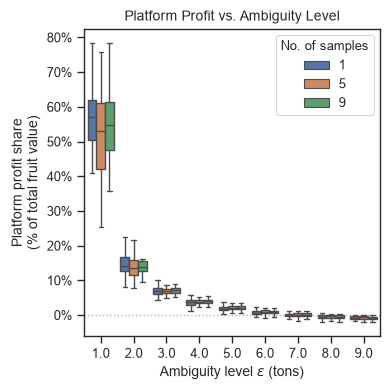

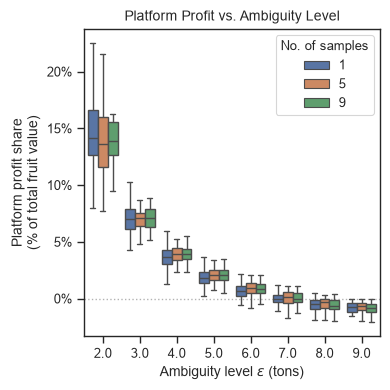

In [9]:
plt.figure(figsize=(4, 4))

ax = sns.boxplot(
    data=df.query("n_hist_sets in [1, 5, 9]"),
    x="avg_epsilon",
    y="platform_profit_pct",
    hue="n_hist_sets",
    showfliers=False,
    palette='deep',
)

plt.axhline(0, color="black", linestyle="dotted", linewidth=1, alpha=0.3, zorder=0)

plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.ylabel("Platform profit share\n(% of total fruit value)")
plt.title("Platform Profit vs. Ambiguity Level")
plt.legend(title="No. of samples")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

plt.tight_layout()
plt.savefig("../figures/exp_5/platform_profit_samples.png", bbox_inches='tight', dpi=300)
plt.show()

plt.figure(figsize=(4, 4))

ax = sns.boxplot(
    data=df.query("n_hist_sets in [1, 5, 9] and avg_epsilon >= 2"),
    x="avg_epsilon",
    y="platform_profit_pct",
    hue="n_hist_sets",
    showfliers=False,
    palette='deep',
)

plt.axhline(0, color="black", linestyle="dotted", linewidth=1, alpha=0.3, zorder=0)

plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.ylabel("Platform profit share\n(% of total fruit value)")
plt.title("Platform Profit vs. Ambiguity Level")
plt.legend(title="No. of samples")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

plt.tight_layout()
plt.savefig("../figures/exp_5/platform_profit_samples_restr.png", bbox_inches='tight', dpi=300)
plt.show()

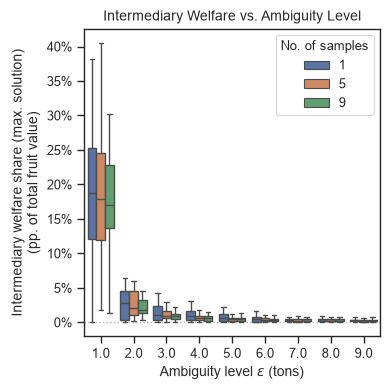

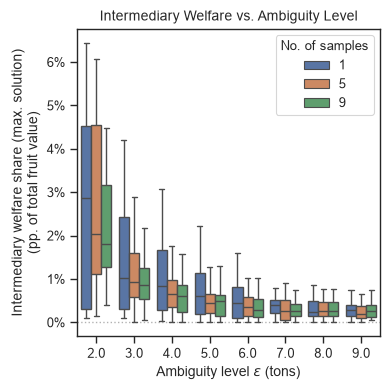

In [10]:
plt.figure(figsize=(4, 4))

ax = sns.boxplot(
    data=df.query("n_hist_sets in [1, 5, 9]"),
    x="avg_epsilon",
    y="max_intermediary_welfare_pct",
    hue="n_hist_sets",
    palette='deep',
    showfliers=False
)

plt.axhline(0, color="black", linestyle="dotted", linewidth=1, alpha=0.3, zorder=0)

plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.ylabel("Intermediary welfare share (max. solution)\n(pp. of total fruit value)")
plt.title("Intermediary Welfare vs. Ambiguity Level")
plt.legend(title="No. of samples")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

plt.tight_layout()
plt.savefig("../figures/exp_5/intermediary_welfare_samples.png", bbox_inches='tight', dpi=300)
plt.show()

plt.figure(figsize=(4, 4))

ax = sns.boxplot(
    data=df.query("n_hist_sets in [1, 5, 9] and avg_epsilon >= 2"),
    x="avg_epsilon",
    y="max_intermediary_welfare_pct",
    hue="n_hist_sets",
    palette='deep',
    showfliers=False
)

plt.axhline(0, color="black", linestyle="dotted", linewidth=1, alpha=0.3, zorder=0)

plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.ylabel("Intermediary welfare share (max. solution)\n(pp. of total fruit value)")
plt.title("Intermediary Welfare vs. Ambiguity Level")
plt.legend(title="No. of samples")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

plt.tight_layout()
plt.savefig("../figures/exp_5/intermediary_welfare_samples_restr.png", bbox_inches='tight', dpi=300)
plt.show()


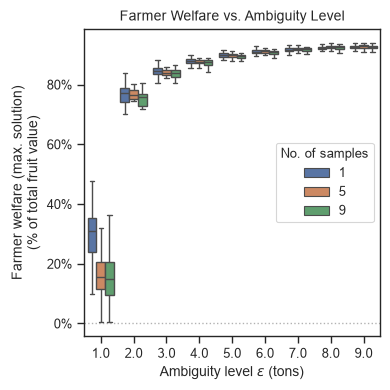

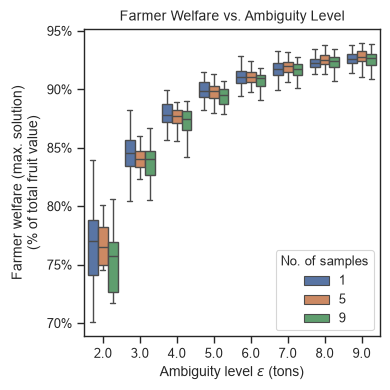

In [11]:
plt.figure(figsize=(4, 4))

ax = sns.boxplot(
    data=df.query("n_hist_sets in [1, 5, 9]"),
    x="avg_epsilon",
    y="max_farmer_welfare_pct",
    hue="n_hist_sets",
    showfliers=False,
    palette='deep',
)

plt.axhline(0, color="black", linestyle="dotted", linewidth=1, alpha=0.3, zorder=0)

plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.ylabel("Farmer welfare (max. solution)\n(% of total fruit value)")
plt.title("Farmer Welfare vs. Ambiguity Level")
plt.legend(title="No. of samples")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

plt.tight_layout()

plt.savefig("../figures/exp_5/farmer_welfar_samples.png", bbox_inches='tight', dpi=300)
plt.show()


plt.figure(figsize=(4, 4))

ax = sns.boxplot(
    data=df.query("n_hist_sets in [1, 5, 9] and avg_epsilon >= 2"),
    x="avg_epsilon",
    y="max_farmer_welfare_pct",
    hue="n_hist_sets",
    showfliers=False,
    palette='deep',
)


plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.ylabel("Farmer welfare (max. solution)\n(% of total fruit value)")
plt.title("Farmer Welfare vs. Ambiguity Level")
plt.legend(title="No. of samples")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

plt.tight_layout()

plt.savefig("../figures/exp_5/farmer_welfar_samples_restr.png", bbox_inches='tight', dpi=300)
plt.show()
